<a href="https://colab.research.google.com/github/tomzavi56/South-Africa-Labour-Market-Analysis/blob/main/01_data_loading_and_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of worksheets: 28

Worksheet names:
['Table of contents', 'Table1', 'Table 2', 'Table2.1', 'Table2.2', 'Table 2.3', 'Table3.1', 'Table3.2', 'Table3.3', 'Table3.4', 'Table3.5', 'Table3.6', 'Table3.6b', 'Table3.6c', 'Table3.7', 'Table3.8a', 'Table3.8b', 'Table3.8c', 'Table3.9', 'Table3.10', 'Table4', 'Table5', 'Table6', 'Table7a', 'Table7b', 'Table7c', 'Table7d', 'Table8']


,0,1,2,3,4,5
0,Table 2: Labour force characteristics by sex -...,NaN,NaN,NaN,NaN,NaN
1,NaN,Jan-Mar 2008,Apr-Jun 2008,Jul-Sep 2008,Oct-Dec 2008,Jan-Mar 2009
2,NaN,Thousand,Thousand,Thousand,Thousand,Thousand
3,NaN,NaN,NaN,NaN,NaN,NaN
4,Both sexes,NaN,NaN,NaN,NaN,NaN
5,Population 15-64 years,31544.169476,31690.004275,31838.561347,31986.737347,32135.250465
6,Labour Force,18808.476851,18851.204272,18847.838392,18816.586047,18981.813708
7,Employed,14437.740356,14584.495164,14548.509536,14768.699092,14615.501907
8,Formal sector,-,-,-,-,-
9,Informal sector,-,-,-,-,-


Number of observations: 74

First five observations:


,quarter,unemployment_rate
0,Jan-Mar 2008,23.2
1,Apr-Jun 2008,22.6
2,Jul-Sep 2008,22.8
3,Oct-Dec 2008,21.5
4,Jan-Mar 2009,23.0



Last five observations:


,quarter,unemployment_rate
69,Apr-Jun 2025,33.2
70,Jul-Sep 2025,31.9
71,Oct-Dec 2025,31.4
72,Jan-Mar 2026,32.7
73,Apr-Jun 2026,33.6


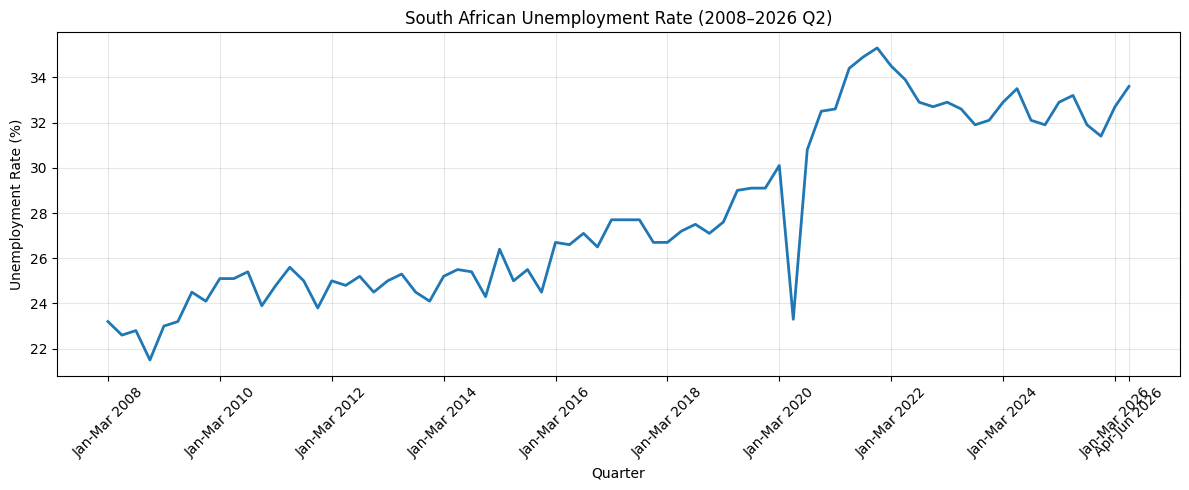

In [7]:

import pandas as pd

excel_file = pd.ExcelFile(filename)

print("Number of worksheets:", len(excel_file.sheet_names))
print("\nWorksheet names:")
print(excel_file.sheet_names)

raw = pd.read_excel(
    filename,
    sheet_name="Table 2",
    header=None
)

display(raw.iloc[:28, :6])

# Extract quarterly dates (Excel row 2)
quarters = raw.iloc[1, 1:]

# Extract national unemployment rates (Excel row 25)
rates = pd.to_numeric(raw.iloc[24, 1:], errors="coerce")

# Create a clean dataframe
unemployment_df = pd.DataFrame({
    "quarter": quarters.to_numpy(),
    "unemployment_rate": rates.to_numpy()
})

unemployment_df = unemployment_df.dropna().reset_index(drop=True)

print("Number of observations:", len(unemployment_df))

print("\nFirst five observations:")
display(unemployment_df.head())

print("\nLast five observations:")
display(unemployment_df.tail())

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    unemployment_df.index,
    unemployment_df["unemployment_rate"],
    linewidth=2
)

ticks = list(range(0, len(unemployment_df), 8))
ticks.append(len(unemployment_df) - 1)

plt.xticks(
    ticks,
    unemployment_df["quarter"].iloc[ticks],
    rotation=45
)

plt.title("South African Unemployment Rate (2008–2026 Q2)")
plt.xlabel("Quarter")
plt.ylabel("Unemployment Rate (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()